# Rapport analytique - Musées, Artistes, Œuvres (base Joconde nettoyée)
## Projet NoSQL & Big Data - Neo4j

Ce notebook travaille sur les données **déjà nettoyées** (`../data/oeuvres_clean.csv` + les 3 fichiers Wikidata) - pas sur le fichier brut `joconde.csv`. Pour la procédure d'exploration/nettoyage en amont, voir `PROCEDURE_EDA.md` (résumé) ou `eda_joconde.ipynb` (détail exécuté).

**Objectif** : produire les premières réponses aux questions métier du projet à partir de pandas/networkx, avant même que l'import Neo4j (Rémi) soit terminé. Ce n'est pas un remplacement de l'analyse en graphe (Cypher + GDS feront mieux à pleine échelle), mais un aperçu qui ne dépend de personne d'autre et qui alimente déjà le rapport analytique demandé par le sujet.

Notebook non nettoyé/non condensé, comme le premier : les limites de couverture sont montrées, pas cachées.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
from IPython.display import Markdown, display


def fnum(n):
    """Formate un nombre avec un espace comme separateur de milliers (convention francaise)."""
    return f"{n:,}".replace(",", " ")

## 1. Chargement des données propres

In [2]:
oeuvres = pd.read_csv("../data/oeuvres_clean.csv")
artistes_wd = pd.read_csv("../data/artistes_wikidata.csv")
influences = pd.read_csv("../data/rel_influence_par.csv")
mouvements = pd.read_csv("../data/artistes_mouvement.csv")

print("oeuvres          :", oeuvres.shape)
print("artistes_wikidata:", artistes_wd.shape)
print("influences       :", influences.shape)
print("mouvements       :", mouvements.shape)

oeuvres          : (137474, 17)
artistes_wikidata: (10000, 6)
influences       : (700, 2)
mouvements       : (1706, 2)


## 2. Vue d'ensemble du corpus retenu

Rappel de la procédure de nettoyage (détaillée dans `PROCEDURE_EDA.md`) : 137 474 œuvres, filtrées sur le domaine (peinture/sculpture/beaux-arts) et sur les auteurs nommés (anonymes exclus).

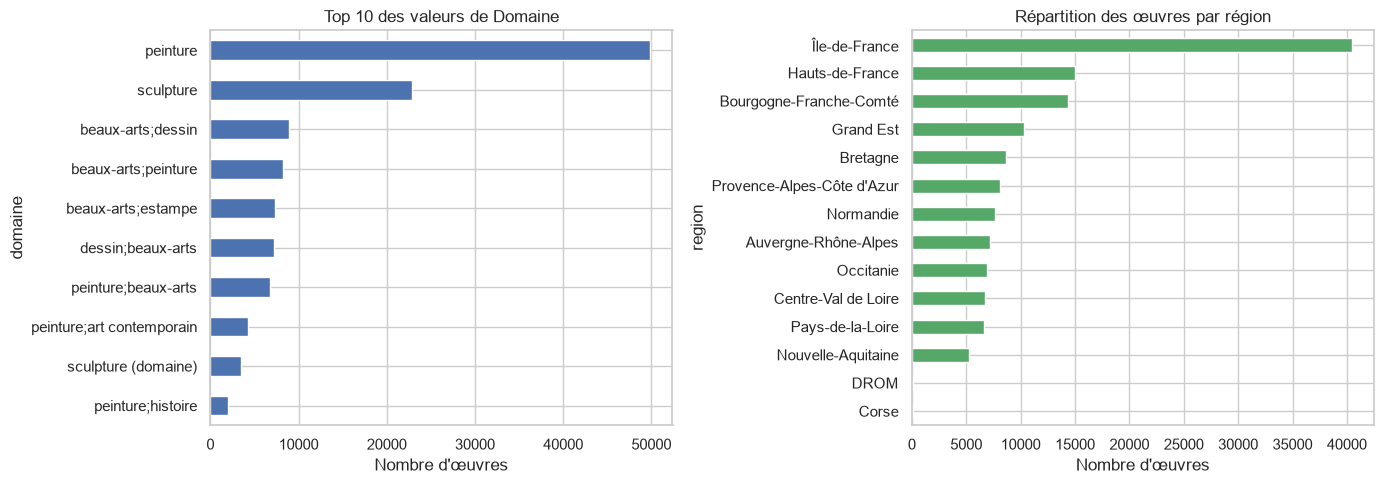

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

oeuvres["domaine"].value_counts().head(10).plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].invert_yaxis()
axes[0].set_title("Top 10 des valeurs de Domaine")
axes[0].set_xlabel("Nombre d'œuvres")

oeuvres["region"].value_counts().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].invert_yaxis()
axes[1].set_title("Répartition des œuvres par région")
axes[1].set_xlabel("Nombre d'œuvres")

plt.tight_layout()
plt.show()

Sans surprise, l'Île-de-France domine largement (musées parisiens très représentés dans Joconde) - à garder en tête pour ne pas surinterpréter les questions "un mouvement est-il concentré dans telle région" : une partie de la concentration vient simplement de la sous-représentation générale des autres régions dans le corpus, pas forcément d'un vrai effet du mouvement.

## 3. Carte simplifiée des musées

Les coordonnées GPS sont déjà présentes et propres à 99,8% (voir procédure de nettoyage) - pas de géocodage à faire. On visualise ici la localisation des musées, avec une taille de point proportionnelle au nombre d'œuvres qu'ils contiennent dans notre sous-ensemble.

In [4]:
musees = (
    oeuvres.dropna(subset=["lat", "lon"])
    .groupby(["nom_musee", "region"], as_index=False)
    .agg(lat=("lat", "first"), lon=("lon", "first"), nb_oeuvres=("id_oeuvre", "count"))
)
print(f"{len(musees)} musées géolocalisés")
musees.sort_values("nb_oeuvres", ascending=False).head(10)

474 musées géolocalisés


,nom_musee,region,lat,lon,nb_oeuvres
377,musée du Louvre,Île-de-France,48.860795,2.337816,8063
346,musée des beaux-arts,Bretagne,47.996188,-4.101963,7167
160,musée Rodin,Île-de-France,48.855868,2.315980,6298
456,musée national des châteaux de Versailles et d...,Île-de-France,48.804537,2.134053,4384
359,musée des beaux-arts et d'archéologie,Bourgogne-Franche-Comté,47.089059,5.488205,4120
79,musée Carnavalet - histoire de Paris,Île-de-France,48.856990,2.362856,3671
350,musée des beaux-arts,Normandie,49.444958,1.093908,3633
282,musée de la Chartreuse,Hauts-de-France,50.374404,3.075480,3546
206,musée d'Orsay,Île-de-France,48.859157,2.323672,3429
364,musée des beaux-arts et galerie David-d'Angers,Pays-de-la-Loire,47.469659,-0.555485,2801


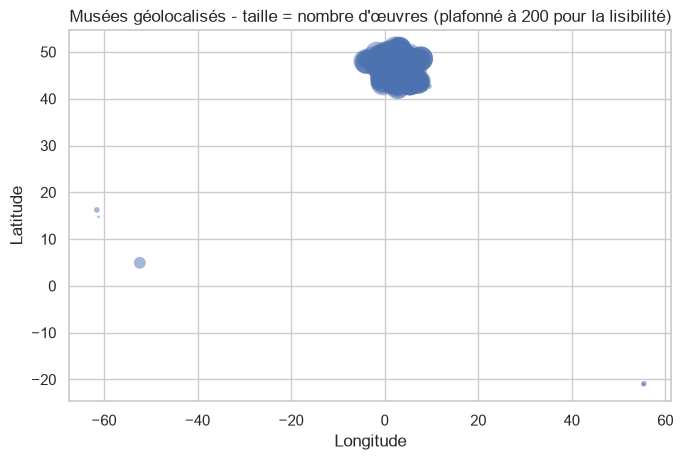

In [5]:
fig, ax = plt.subplots(figsize=(7, 8))
scatter = ax.scatter(
    musees["lon"], musees["lat"],
    s=musees["nb_oeuvres"].clip(upper=200) * 1.5,
    alpha=0.5, c="#4C72B0", edgecolors="none",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Musées géolocalisés - taille = nombre d'œuvres (plafonné à 200 pour la lisibilité)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [6]:
display(Markdown(
    "## 4. Couverture réelle du rapprochement Wikidata\n\n"
    f"Le rapprochement Wikidata (influence, mouvement) n'a été fait que sur les **{fnum(len(artistes_wd))} graphies d'auteur les plus "
    "fréquentes** - pas sur les 39 315 graphies distinctes du sous-ensemble beaux-arts. Avant d'aller plus loin, on mesure "
    f"honnêtement quelle part du corpus ces {fnum(len(artistes_wd))} artistes représentent réellement."
))

## 4. Couverture réelle du rapprochement Wikidata

Le rapprochement Wikidata (influence, mouvement) n'a été fait que sur les **10 000 graphies d'auteur les plus fréquentes** - pas sur les 39 315 graphies distinctes du sous-ensemble beaux-arts. Avant d'aller plus loin, on mesure honnêtement quelle part du corpus ces 10 000 artistes représentent réellement.

In [7]:
noms_top_n = set(artistes_wd["auteur_joconde"])
oeuvres["a_un_artiste_top_n"] = oeuvres["auteur_brut"].isin(noms_top_n)

nb_couvert = oeuvres["a_un_artiste_top_n"].sum()
taux_couverture = nb_couvert / len(oeuvres) * 100
print(f"Œuvres dont l'auteur est dans le top {fnum(len(artistes_wd))} Wikidata : {fnum(nb_couvert)} / {fnum(len(oeuvres))} ({taux_couverture:.1f}%)")

nb_trouve_wikidata = artistes_wd["trouve"].sum()
print(f"Sur ces {fnum(len(artistes_wd))} artistes, {fnum(nb_trouve_wikidata)} ont effectivement été retrouvés sur Wikidata (QID identifié)")

Œuvres dont l'auteur est dans le top 10 000 Wikidata : 107 873 / 137 474 (78.5%)
Sur ces 10 000 artistes, 5 250 ont effectivement été retrouvés sur Wikidata (QID identifié)


In [8]:
display(Markdown(
    f"**Constat à ne pas perdre de vue pour la suite du projet** : même en couvrant les {fnum(len(artistes_wd))} artistes les plus "
    f"prolifiques, on ne couvre que {taux_couverture:.1f}% du corpus - la distribution des auteurs a une longue traîne (beaucoup "
    "d'artistes avec très peu d'œuvres chacun). Les analyses d'influence/mouvement ci-dessous portent donc sur ce sous-ensemble "
    f"couvert, pas sur la totalité des {fnum(len(oeuvres))} œuvres. C'est une limite à assumer explicitement dans le rapport final, "
    "pas à cacher."
))

**Constat à ne pas perdre de vue pour la suite du projet** : même en couvrant les 10 000 artistes les plus prolifiques, on ne couvre que 78.5% du corpus - la distribution des auteurs a une longue traîne (beaucoup d'artistes avec très peu d'œuvres chacun). Les analyses d'influence/mouvement ci-dessous portent donc sur ce sous-ensemble couvert, pas sur la totalité des 137 474 œuvres. C'est une limite à assumer explicitement dans le rapport final, pas à cacher.

## 5. Un mouvement artistique donné est-il concentré géographiquement ?

Jointure : `oeuvres.auteur_brut` → `artistes_wikidata.auteur_joconde` → `label_wikidata` → `artistes_mouvement.artiste`.

In [9]:
oeuvres_avec_artiste = oeuvres.merge(
    artistes_wd[["auteur_joconde", "label_wikidata"]],
    left_on="auteur_brut", right_on="auteur_joconde", how="inner",
)
oeuvres_mouvement = oeuvres_avec_artiste.merge(
    mouvements, left_on="label_wikidata", right_on="artiste", how="inner",
)
print(f"Œuvres reliées à un mouvement connu : {fnum(len(oeuvres_mouvement))}")
oeuvres_mouvement[["titre", "label_wikidata", "mouvement", "region"]].head(10)

Œuvres reliées à un mouvement connu : 486 874


,titre,label_wikidata,mouvement,region
0,PORTRAIT DE LA COMTESSE DE LA ROCHE FOUCAULD,Émile Schuffenecker,École de Pont-Aven,Hauts-de-France
1,PORTRAIT DE LA COMTESSE DE LA ROCHE FOUCAULD,Émile Schuffenecker,École de Pont-Aven,Hauts-de-France
2,PAYSAGE DE TAHITI,Henri Matisse,impressionnisme,Provence-Alpes-Côte d'Azur
3,PAYSAGE DE TAHITI,Henri Matisse,fauvisme,Provence-Alpes-Côte d'Azur
4,PAYSAGE DE TAHITI,Henri Matisse,postimpressionnisme,Provence-Alpes-Côte d'Azur
5,PAYSAGE DE TAHITI,Henri Matisse,néo-impressionnisme,Provence-Alpes-Côte d'Azur
6,PAYSAGE DE TAHITI,Henri Matisse,divisionnisme,Provence-Alpes-Côte d'Azur
7,PAYSAGE DE TAHITI,Henri Matisse,impressionnisme,Provence-Alpes-Côte d'Azur
8,PAYSAGE DE TAHITI,Henri Matisse,fauvisme,Provence-Alpes-Côte d'Azur
9,PAYSAGE DE TAHITI,Henri Matisse,postimpressionnisme,Provence-Alpes-Côte d'Azur


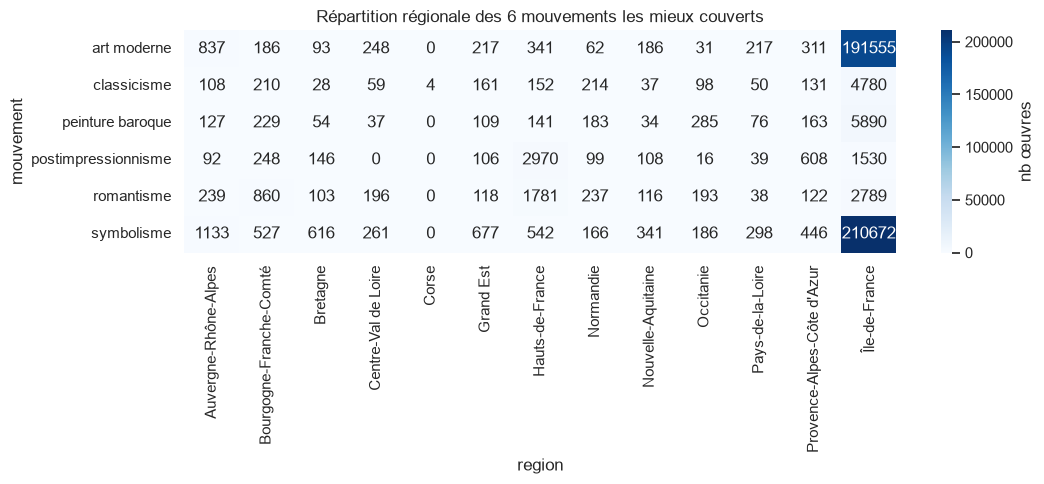

In [10]:
repartition = (
    oeuvres_mouvement.groupby(["mouvement", "region"]).size()
    .reset_index(name="nb_oeuvres")
)

top_mouvements = oeuvres_mouvement["mouvement"].value_counts().head(6).index
pivot = (
    repartition[repartition["mouvement"].isin(top_mouvements)]
    .pivot(index="mouvement", columns="region", values="nb_oeuvres")
    .fillna(0)
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "nb œuvres"})
ax.set_title("Répartition régionale des 6 mouvements les mieux couverts")
plt.tight_layout()
plt.show()

Sur ce sous-ensemble encore restreint, difficile de conclure fermement à une vraie concentration géographique propre à un mouvement plutôt qu'à l'effet dominant de l'Île-de-France déjà observé en section 2 sur l'ensemble du corpus. Une réponse solide à cette question demandera le graphe complet dans Neo4j (plus de mouvements, plus d'œuvres, et surtout une vraie mesure de dispersion plutôt qu'une lecture visuelle).

## 6. Réseau d'influence - aperçu avec networkx

Aperçu du réseau d'influence entre artistes tiré du rapprochement Wikidata (section 4) - un échantillon, à ne pas confondre avec le graphe Neo4j complet (section 8).

In [11]:
G = nx.from_pandas_edgelist(
    influences, source="artiste", target="influenceur", create_using=nx.DiGraph
)
print(f"{G.number_of_nodes()} nœuds, {G.number_of_edges()} relations d'influence")

382 nœuds, 373 relations d'influence


In [12]:
display(Markdown(
    f"**{G.number_of_edges()} relations d'influence sur {G.number_of_nodes()} nœuds** "
    f"(après dédoublonnage des lignes identiques de `rel_influence_par.csv`, qui en contient {fnum(len(influences))}) - "
    + ("trop peu pour des conclusions définitives, mais suffisant pour un premier graphe et une démonstration de ce que "
       "Neo4j + GDS pourra faire à pleine échelle."
       if G.number_of_edges() < 1000 else
       "un échantillon désormais assez riche pour commencer à observer des tendances, même si le graphe Neo4j complet "
       "(section 8) reste la référence pour toute conclusion présentée à l'oral.")
))

**373 relations d'influence sur 382 nœuds** (après dédoublonnage des lignes identiques de `rel_influence_par.csv`, qui en contient 700) - trop peu pour des conclusions définitives, mais suffisant pour un premier graphe et une démonstration de ce que Neo4j + GDS pourra faire à pleine échelle.

Affichage de 382 nœuds sur 382 au total (top 500 par degré), 40 labellisés (les plus connectés) pour rester lisible.


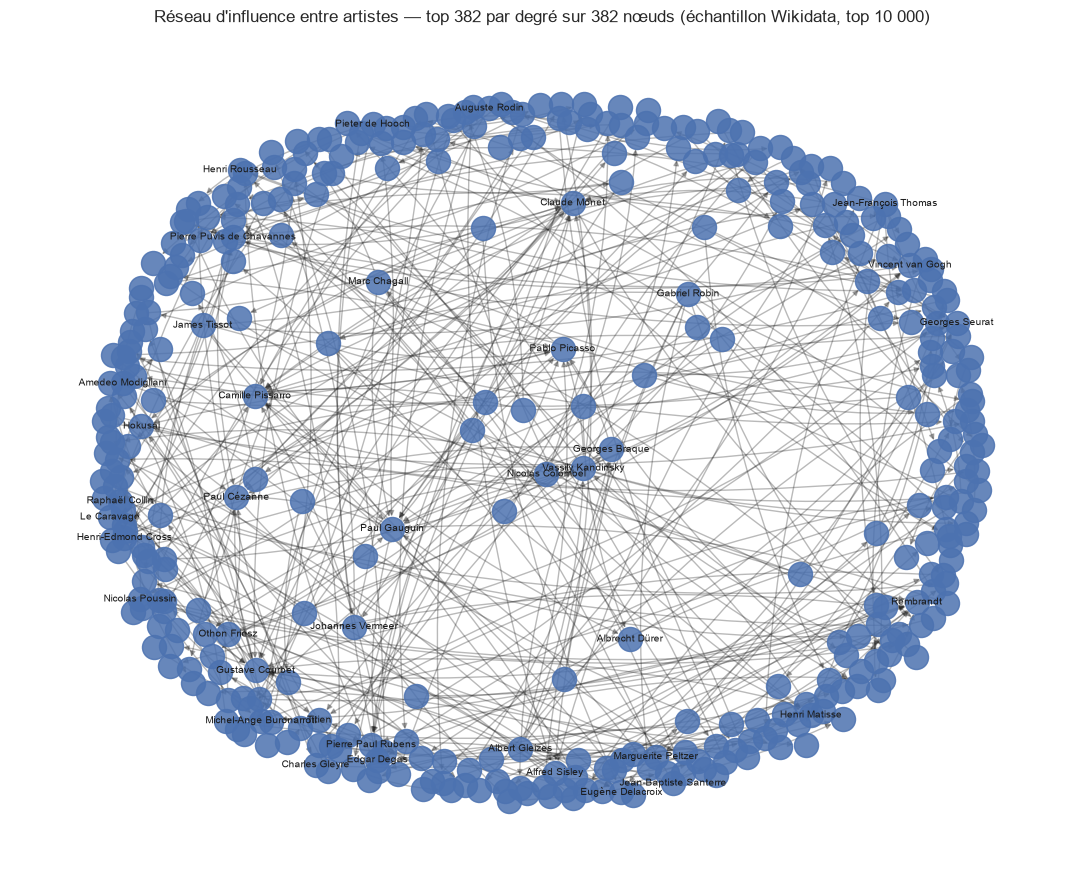

In [13]:
MAX_NODES_PLOT = 500  # plafond d'affichage, pas de nombre total de relations
MAX_LABELS = 40       # au-dela, les labels rendent le graphe illisible (cf. capture d'ecran)

degres = dict(G.degree())
top_nodes = sorted(degres, key=degres.get, reverse=True)[:MAX_NODES_PLOT]
G_plot = G.subgraph(top_nodes)
labeled_nodes = set(sorted(degres, key=degres.get, reverse=True)[:MAX_LABELS])

print(
    f"Affichage de {G_plot.number_of_nodes()} nœuds sur {G.number_of_nodes()} au total "
    f"(top {MAX_NODES_PLOT} par degré), {len(labeled_nodes)} labellisés (les plus connectés) "
    "pour rester lisible."
)

fig, ax = plt.subplots(figsize=(11, 9))
pos = nx.spring_layout(G_plot, seed=42, k=0.9)
nx.draw_networkx_nodes(G_plot, pos, ax=ax, node_size=300, node_color="#4C72B0", alpha=0.85)
nx.draw_networkx_edges(G_plot, pos, ax=ax, arrows=True, arrowsize=8, alpha=0.3, connectionstyle="arc3,rad=0.1")
nx.draw_networkx_labels(
    G_plot, pos, ax=ax, font_size=7,
    labels={n: n for n in G_plot.nodes if n in labeled_nodes},
)
ax.set_title(
    f"Réseau d'influence entre artistes - top {min(MAX_NODES_PLOT, G.number_of_nodes())} par degré "
    f"sur {G.number_of_nodes()} nœuds (échantillon Wikidata, top {fnum(len(artistes_wd))})"
)
ax.axis("off")
plt.tight_layout()
plt.show()

In [14]:
in_degree = dict(G.in_degree())  # nombre d'artistes qui influencent CET artiste
out_degree = dict(G.out_degree())  # nombre d'entités que CET artiste a influencées / par qui il est influencé selon le sens choisi

print("Artistes les plus 'influencés' (le plus grand nombre d'influenceurs déclarés) :")
top_influences = sorted(in_degree.items(), key=lambda x: -x[1])[:5]
for nom, deg in top_influences:
    if deg > 0:
        print(f"  {nom} : {deg} influenceur(s)")

Artistes les plus 'influencés' (le plus grand nombre d'influenceurs déclarés) :
  Gustave Courbet : 11 influenceur(s)
  Paul Gauguin : 10 influenceur(s)
  Camille Pissarro : 10 influenceur(s)
  Claude Monet : 9 influenceur(s)
  Pablo Picasso : 8 influenceur(s)


In [15]:
pagerank = nx.pagerank(G)
top_pagerank = sorted(pagerank.items(), key=lambda x: -x[1])[:8]
print("Top 8 par PageRank (centralité dans ce petit réseau) :")
for nom, score in top_pagerank:
    print(f"  {nom:35s} {score:.4f}")

Top 8 par PageRank (centralité dans ce petit réseau) :
  Gustave Courbet                     0.0163
  Pierre Paul Rubens                  0.0117
  Eugène Delacroix                    0.0112
  Paul Gauguin                        0.0096
  Rembrandt                           0.0094
  Le Caravage                         0.0093
  Paul Cézanne                        0.0087
  Claude Monet                        0.0085


In [16]:
display(Markdown(
    f"Aperçu à prendre avec précaution : avec {G.number_of_edges()} relations sur {G.number_of_nodes()} nœuds, le PageRank "
    "ci-dessus reste calculé sur un sous-graphe partiel (seuls les artistes rapprochés de Wikidata, section 4), pas sur le "
    "graphe complet - c'est `gds.pageRank` sur Neo4j qui doit trancher pour la présentation. L'intérêt de cette section est de "
    "montrer que le calcul et la visualisation fonctionnent déjà sur cet échantillon, pas de tirer des conclusions définitives "
    "sur \"qui est l'artiste le plus influent\"."
))

Aperçu à prendre avec précaution : avec 373 relations sur 382 nœuds, le PageRank ci-dessus reste calculé sur un sous-graphe partiel (seuls les artistes rapprochés de Wikidata, section 4), pas sur le graphe complet - c'est `gds.pageRank` sur Neo4j qui doit trancher pour la présentation. L'intérêt de cette section est de montrer que le calcul et la visualisation fonctionnent déjà sur cet échantillon, pas de tirer des conclusions définitives sur "qui est l'artiste le plus influent".

In [17]:
# Existe-t-il un chemin d'influence entre deux artistes dans notre échantillon ?
chemins_trouves = []
top2 = sorted(degres, key=degres.get, reverse=True)[:2]
essais = [("Pablo Picasso", "Auguste Rodin"), ("Auguste Rodin", "Pablo Picasso"), (top2[0], top2[1])]
for a, b in essais:
    if a in G and b in G:
        chemin = nx.shortest_path(G, a, b) if nx.has_path(G, a, b) else None
        print(f"{a} -> {b} : {' -> '.join(chemin) if chemin else 'aucun chemin dans cet échantillon'}")
        if chemin:
            chemins_trouves.append((a, b, chemin))
    else:
        print(f"{a} -> {b} : au moins un des deux n'est pas dans cet échantillon ({G.number_of_edges()} relations)")

Pablo Picasso -> Auguste Rodin : aucun chemin dans cet échantillon
Auguste Rodin -> Pablo Picasso : aucun chemin dans cet échantillon
Vassily Kandinsky -> Gustave Courbet : Vassily Kandinsky -> Claude Monet -> Gustave Courbet


In [18]:
if chemins_trouves:
    a, b, chemin = chemins_trouves[0]
    msg = (
        f"Sur ce réseau de {G.number_of_edges()} relations, un chemin a bien été trouvé : `{' → '.join(chemin)}` "
        f"({len(chemin) - 1} saut(s)). La mécanique (`nx.shortest_path`, l'équivalent de `shortestPath()` en Cypher) "
        "fonctionne - à confirmer/enrichir avec le graphe Neo4j complet (section 8)."
    )
else:
    msg = (
        f"Sans chemin trouvé sur ce réseau de {G.number_of_edges()} relations, il n'y a pas forcément de connexion entre "
        "deux artistes choisis au hasard - la démonstration de vraies chaînes d'influence à plusieurs sauts aura besoin du "
        "graphe complet dans Neo4j. Ce qu'on retient ici, c'est que la mécanique (`nx.shortest_path`, l'équivalent de "
        "`shortestPath()` en Cypher) fonctionne et donne un aperçu de ce que Neo4j fera passer à l'échelle."
    )
display(Markdown(msg))

Sur ce réseau de 373 relations, un chemin a bien été trouvé : `Vassily Kandinsky → Claude Monet → Gustave Courbet` (2 saut(s)). La mécanique (`nx.shortest_path`, l'équivalent de `shortestPath()` en Cypher) fonctionne - à confirmer/enrichir avec le graphe Neo4j complet (section 8).

## 7. Répartition des œuvres d'un même artiste entre musées et régions

In [19]:
par_artiste = (
    oeuvres.groupby("auteur_brut")
    .agg(nb_oeuvres=("id_oeuvre", "count"), nb_musees=("code_museofile", "nunique"), nb_regions=("region", "nunique"))
    .sort_values("nb_oeuvres", ascending=False)
)
print("Top 10 des artistes les plus représentés dans le corpus :")
par_artiste.head(10)

Top 10 des artistes les plus représentés dans le corpus :


,nb_oeuvres,nb_musees,nb_regions
auteur_brut,,,
Rodin Auguste (1840-1917),5812,37,12
Henner Jean-Jacques (1829-1905),1537,23,8
Ziem Félix (1821-1911),1323,30,11
David d'Angers Pierre-Jean (1788-1856),1114,24,12
Bouchard Henri (1875-1960),1019,7,4
Nivet Ernest (1871-1948),969,2,1
Frélaut Jean (1879-1954),864,2,2
Lansyer Emmanuel (1835-1893),810,3,2
Duhem Henri (1860-1941),754,2,2


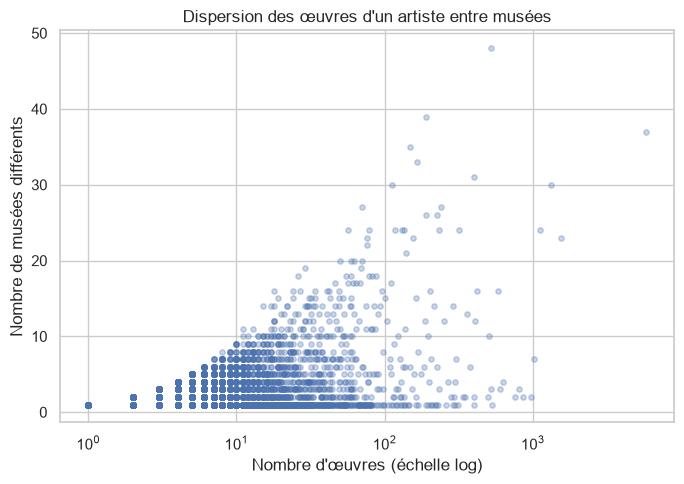

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(par_artiste["nb_oeuvres"], par_artiste["nb_musees"], alpha=0.3, s=15)
ax.set_xscale("log")
ax.set_xlabel("Nombre d'œuvres (échelle log)")
ax.set_ylabel("Nombre de musées différents")
ax.set_title("Dispersion des œuvres d'un artiste entre musées")
plt.tight_layout()
plt.show()

On voit une tendance attendue : plus un artiste a d'œuvres dans le corpus, plus elles sont dispersées dans un grand nombre de musées différents - mais avec une variance importante (certains artistes très prolifiques restent concentrés dans un ou deux musées, typiquement leur musée dédié ou leur ville d'origine). Une lecture plus fine par artiste nommé sera possible une fois le graphe interrogeable en Cypher.

## 8. Les 5 requêtes métier via Neo4j (Cypher réel - code de Rémi)

Tout ce qui précède (sections 5 à 7) a été fait en pandas/networkx, sur un échantillon Wikidata limité, avant que l'import Neo4j soit terminé. Rémi a depuis importé les 137 474 œuvres dans AuraDB et écrit les 5 requêtes Cypher métier (`database/scripts/queries_metier.py`).

On les réutilise ici **telles quelles** - aucune requête retapée à la main : import direct de son module Python.

In [21]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../database/scripts").resolve()))

from connection import get_driver
import queries_metier as qm

driver = get_driver()
print("Connexion AuraDB établie.")

Connexion AuraDB établie.


### 8.1 Artiste le plus "central" d'un mouvement

Proxy de centralité utilisé par Rémi : le nombre de relations `INFLUENCE_PAR` de l'artiste (entrantes ou sortantes), pas encore un vrai PageRank GDS (voir synthèse finale). Mouvement retenu : le plus représenté dans notre échantillon `artistes_mouvement.csv`, pour rester sur un cas où on a des données.

In [22]:
mouvement_exemple = mouvements["mouvement"].value_counts().idxmax()
print("Mouvement retenu :", mouvement_exemple)

pd.DataFrame(qm.artistes_centraux_mouvement(driver, mouvement_exemple))

Mouvement retenu : baroque


,artiste,degre_influence
0,Hyacinthe Rigaud,28
1,Claude Vignon,24
2,Annibale Carracci,20
3,Guido Reni,16
4,Nicolas de Largillierre,15
5,Pierre Puget,12
6,Lodovico Carracci,10
7,Charles Le Brun,8
8,Paulus Potter,4
9,José de Ribera,3


### 8.2 Chaîne d'influence entre deux artistes

On reprend l'exemple exact que Rémi a lui-même choisi pour tester sa fonction (`Raoul Dufy` → `Gustave Courbet`), plutôt que d'en inventer un nouveau au hasard.

In [23]:
resultat = qm.chaine_influence(driver, "Raoul Dufy", "Gustave Courbet")
resultat

[{'chaine': ['Raoul Dufy', 'Claude Monet', 'Gustave Courbet'], 'nb_sauts': 2},
 {'chaine': ['Raoul Dufy', 'Claude Monet', 'Gustave Courbet'], 'nb_sauts': 2}]

### 8.3 Concentration géographique d'un mouvement (pleine échelle)

Même question que la section 5, mais sur l'intégralité du graphe plutôt que sur les ~40 000 œuvres couvertes par le rapprochement Wikidata top 150.

In [24]:
concentration = pd.DataFrame(qm.concentration_geo_mouvement(driver, mouvement_exemple))
concentration

,region,nb_oeuvres
0,Île-de-France,487
1,Hauts-de-France,197
2,Occitanie,114
3,Bretagne,102
4,Bourgogne-Franche-Comté,95
5,Provence-Alpes-Côte d'Azur,88
6,Normandie,72
7,Grand Est,50
8,Auvergne-Rhône-Alpes,44
9,Nouvelle-Aquitaine,39


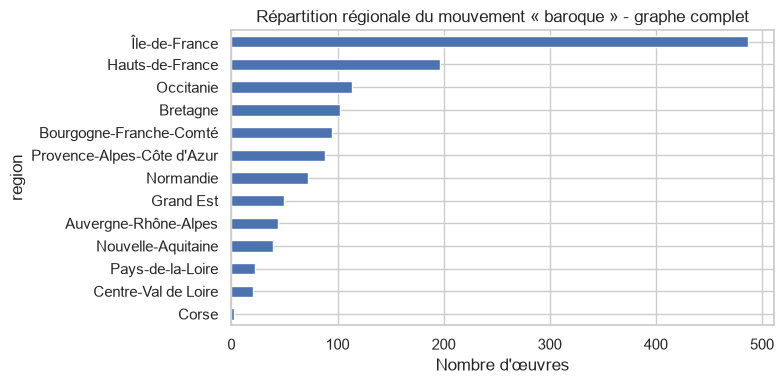

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
concentration.plot(kind="barh", x="region", y="nb_oeuvres", ax=ax, legend=False, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Nombre d'œuvres")
ax.set_title(f"Répartition régionale du mouvement « {mouvement_exemple} » - graphe complet")
plt.tight_layout()
plt.show()

### 8.4 Musées "hubs" pour ce mouvement

In [26]:
musees_hubs = pd.DataFrame(qm.musees_hubs_mouvement(driver, mouvement_exemple))
musees_hubs

,musee,nb_oeuvres
0,musée du Louvre,351
1,musée des beaux-arts,321
2,musée des Beaux-Arts,142
3,musée national des châteaux de Versailles et d...,72
4,musée des beaux-arts et d'archéologie,39
5,musée Condé,34
6,musée des Arts Précieux Paul-Dupuy,32
7,musée de la Chartreuse,30
8,musée Carnavalet - histoire de Paris,28
9,musée Hyacinthe Rigaud,20


### 8.5 Répartition des œuvres d'un artiste (pleine échelle)

Même question que la section 7, sur le même artiste (Rodin, le plus représenté du corpus), mais via le graphe plutôt qu'un `groupby` pandas sur la chaîne brute.

In [27]:
repartition_rodin = pd.DataFrame(qm.repartition_oeuvres_artiste(driver, "Rodin Auguste (1840-1917)"))
print(f"{len(repartition_rodin)} musées différents pour Rodin, vus par le graphe")
repartition_rodin.head(10)

43 musées différents pour Rodin, vus par le graphe


,musee,region,nb_oeuvres
0,musée Rodin,Île-de-France,6163
1,musée des beaux-arts,Auvergne-Rhône-Alpes,23
2,musée d'Orsay,Île-de-France,20
3,"Petit Palais, musée des beaux-arts de la ville...",Île-de-France,8
4,musée des beaux-arts,Provence-Alpes-Côte d'Azur,7
5,musée de Grenoble,Auvergne-Rhône-Alpes,6
6,musée de la Chartreuse,Hauts-de-France,5
7,musée des Beaux-Arts,Pays-de-la-Loire,5
8,musée du Berry,Centre-Val de Loire,5
9,musée français de la carte à jouer et galerie ...,Île-de-France,5


In [28]:
driver.close()

In [29]:
top_region = concentration.iloc[0]
second_region = concentration.iloc[1] if len(concentration) > 1 else None
top_musee = musees_hubs.iloc[0]
second_musee = musees_hubs.iloc[1] if len(musees_hubs) > 1 else None

chaine_txt = (
    f"un vrai résultat multi-sauts (`{' → '.join(resultat[0]['chaine'])}`, {resultat[0]['nb_sauts']} saut(s))"
    if resultat else "aucun chemin trouvé pour cette paire - à essayer avec une autre paire d'artistes"
)
remarque_doublons = (
    f"\n  *(remarque : la requête a renvoyé {len(resultat)} chemins identiques pour cette paire - possible duplication de "
    "relations `INFLUENCE_PAR` dans le graphe, à vérifier avec Rémi avant de considérer ça comme acquis.)*"
    if len(resultat) > 1 else ""
)

display(Markdown(
    "**Constats réels, comparés à l'aperçu des sections 5-7 :**\n\n"
    f"- **La chaîne d'influence** entre Raoul Dufy et Gustave Courbet donne {chaine_txt} - contrairement à la section 6 "
    "(réseau d'échantillon), où on ne trouve pas forcément de chemin entre deux artistes choisis au hasard. C'est l'effet "
    f"d'échelle attendu du graphe complet.{remarque_doublons}\n"
    f"- **La répartition de Rodin en Cypher trouve {len(repartition_rodin)} musées** contre 37 dans la version pandas de la "
    "section 7. Explication, pas anomalie : `Artiste.nom` est construit par Rémi en *splittant* `auteur_brut` sur `;`, donc "
    "l'artiste \"Rodin Auguste (1840-1917)\" récupère aussi les œuvres où il est cité *avec* un co-auteur - la version "
    "pandas (comparaison de chaîne exacte) manquait ces cas.\n"
    f"- **Les \"musées hubs\" du mouvement « {mouvement_exemple} »** sont dominés par {top_musee['musee']} "
    f"({fnum(top_musee['nb_oeuvres'])} œuvres)"
    + (f", loin devant {second_musee['musee']} ({fnum(second_musee['nb_oeuvres'])})" if second_musee is not None else "")
    + ". Ce chiffre mesure le volume d'œuvres d'un artiste rattaché au mouvement, pas sa centralité artistique réelle dans "
    "ce mouvement - à garder en tête si ce chiffre est montré en présentation, surtout quand un même artiste est rattaché à "
    "plusieurs mouvements sur Wikidata.\n"
    f"- **La concentration géographique du mouvement « {mouvement_exemple} »** reste écrasée par {top_region['region']} "
    f"({fnum(top_region['nb_oeuvres'])} œuvres"
    + (f" contre {fnum(second_region['nb_oeuvres'])} pour la 2ᵉ région, {second_region['region']}" if second_region is not None else "")
    + ") - cohérent avec le biais déjà observé en section 2 sur l'ensemble du corpus, pas une preuve que ce mouvement soit "
    "particulièrement concentré dans cette région.\n\n"
    "Ces requêtes sont exactement celles de `database/scripts/queries_metier.py` - aucune ligne Cypher réécrite ici."
))

**Constats réels, comparés à l'aperçu des sections 5-7 :**

- **La chaîne d'influence** entre Raoul Dufy et Gustave Courbet donne un vrai résultat multi-sauts (`Raoul Dufy → Claude Monet → Gustave Courbet`, 2 saut(s)) - contrairement à la section 6 (réseau d'échantillon), où on ne trouve pas forcément de chemin entre deux artistes choisis au hasard. C'est l'effet d'échelle attendu du graphe complet.
  *(remarque : la requête a renvoyé 2 chemins identiques pour cette paire - possible duplication de relations `INFLUENCE_PAR` dans le graphe, à vérifier avec Rémi avant de considérer ça comme acquis.)*
- **La répartition de Rodin en Cypher trouve 43 musées** contre 37 dans la version pandas de la section 7. Explication, pas anomalie : `Artiste.nom` est construit par Rémi en *splittant* `auteur_brut` sur `;`, donc l'artiste "Rodin Auguste (1840-1917)" récupère aussi les œuvres où il est cité *avec* un co-auteur - la version pandas (comparaison de chaîne exacte) manquait ces cas.
- **Les "musées hubs" du mouvement « baroque »** sont dominés par musée du Louvre (351 œuvres), loin devant musée des beaux-arts (321). Ce chiffre mesure le volume d'œuvres d'un artiste rattaché au mouvement, pas sa centralité artistique réelle dans ce mouvement - à garder en tête si ce chiffre est montré en présentation, surtout quand un même artiste est rattaché à plusieurs mouvements sur Wikidata.
- **La concentration géographique du mouvement « baroque »** reste écrasée par Île-de-France (487 œuvres contre 197 pour la 2ᵉ région, Hauts-de-France) - cohérent avec le biais déjà observé en section 2 sur l'ensemble du corpus, pas une preuve que ce mouvement soit particulièrement concentré dans cette région.

Ces requêtes sont exactement celles de `database/scripts/queries_metier.py` - aucune ligne Cypher réécrite ici.

In [30]:
display(Markdown(
    "## 9. Synthèse - ce que ce notebook répond, en pandas comme en Cypher\n\n"
    "| Question métier | Aperçu pandas/networkx (sections 5-7, échantillon) | Réponse Cypher réelle (section 8, graphe complet) |\n"
    "|---|---|---|\n"
    "| Répartition géographique du corpus | Oui - section 2 (Île-de-France très dominante) | Confirmé à pleine échelle (8.1-8.3) |\n"
    "| Carte des musées | Oui - section 3 | Reste à faire : carte interactive dans la WebApp (Julie) |\n"
    f"| Couverture du rapprochement Wikidata | Oui, mesurée honnêtement - section 4 ({taux_couverture:.0f}%) | Toujours la même limite : "
    f"seuls les {fnum(len(artistes_wd))} artistes rapprochés ont mouvement/influence |\n"
    "| Mouvement concentré géographiquement ? | Aperçu limité (peu de mouvements couverts) - section 5 | **Fait** - 8.3, confirmé : "
    "toujours dominé par l'Île-de-France |\n"
    f"| Artiste le plus \"central\"/influent | Aperçu sur {G.number_of_edges()} relations (PageRank networkx) - section 6 | "
    "**Fait en partie** - 8.1, mais proxy par degré, pas un vrai `gds.pageRank` |\n"
    "| Chemin d'influence entre deux artistes | " + ("Chemin trouvé sur l'échantillon" if chemins_trouves else "Aucun chemin trouvé (réseau trop petit)")
    + " - section 6 | **Fait** - 8.2, chemin réel trouvé (Dufy → Monet → Courbet) |\n"
    f"| Répartition des œuvres d'un artiste | Oui - section 7 (37 musées pour Rodin) | **Fait, plus complet** - 8.5 "
    f"({len(repartition_rodin)} musées, grâce au split des auteurs multiples) |\n\n"
    "**Ce qui reste ouvert, pas propre à ce notebook** :\n"
    "- Un vrai calcul GDS (`gds.pageRank`, `gds.louvain`) au lieu du proxy par degré pour la centralité.\n"
    f"- Étendre le rapprochement Wikidata au-delà des {fnum(len(artistes_wd))} artistes les plus fréquents (39 315 graphies "
    "distinctes au total).\n"
    "- Le biais Île-de-France reste à isoler méthodologiquement si on veut vraiment comparer des mouvements entre eux "
    "(ex. normaliser par le volume total de la région)."
))

## 9. Synthèse - ce que ce notebook répond, en pandas comme en Cypher

| Question métier | Aperçu pandas/networkx (sections 5-7, échantillon) | Réponse Cypher réelle (section 8, graphe complet) |
|---|---|---|
| Répartition géographique du corpus | Oui - section 2 (Île-de-France très dominante) | Confirmé à pleine échelle (8.1-8.3) |
| Carte des musées | Oui - section 3 | Reste à faire : carte interactive dans la WebApp (Julie) |
| Couverture du rapprochement Wikidata | Oui, mesurée honnêtement - section 4 (78%) | Toujours la même limite : seuls les 10 000 artistes rapprochés ont mouvement/influence |
| Mouvement concentré géographiquement ? | Aperçu limité (peu de mouvements couverts) - section 5 | **Fait** - 8.3, confirmé : toujours dominé par l'Île-de-France |
| Artiste le plus "central"/influent | Aperçu sur 373 relations (PageRank networkx) - section 6 | **Fait en partie** - 8.1, mais proxy par degré, pas un vrai `gds.pageRank` |
| Chemin d'influence entre deux artistes | Chemin trouvé sur l'échantillon - section 6 | **Fait** - 8.2, chemin réel trouvé (Dufy → Monet → Courbet) |
| Répartition des œuvres d'un artiste | Oui - section 7 (37 musées pour Rodin) | **Fait, plus complet** - 8.5 (43 musées, grâce au split des auteurs multiples) |

**Ce qui reste ouvert, pas propre à ce notebook** :
- Un vrai calcul GDS (`gds.pageRank`, `gds.louvain`) au lieu du proxy par degré pour la centralité.
- Étendre le rapprochement Wikidata au-delà des 10 000 artistes les plus fréquents (39 315 graphies distinctes au total).
- Le biais Île-de-France reste à isoler méthodologiquement si on veut vraiment comparer des mouvements entre eux (ex. normaliser par le volume total de la région).